# Superstore Dataset - EDA & Data Cleaning


## Project Objective
The goal of this project is to explore the Superstore dataset, clean the data, identify patterns, detect issues, and prepare the dataset for further analysis and visualization.

## Dataset
Sample Superstore Dataset

## Tools & Libraries
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

# 1) Import Libraries

In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

# Style
sns.set_style("whitegrid")

# 2) Load Dataset

In [83]:
from google.colab import files
uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore (2).csv


In [84]:
# Some Kaggle datasets may require a different encoding format
df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')


# 3) Dataset Preview

In [85]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [86]:
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,Florida,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2017-119914,5/4/2017,5/9/2017,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,California,92683,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


In [87]:
df.sample(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
764,765,CA-2014-162775,1/13/2014,1/15/2014,Second Class,CS-12250,Chris Selesnick,Corporate,United States,Bossier City,Louisiana,71111,South,OFF-EN-10001532,Office Supplies,Envelopes,Brown Kraft Recycled Envelopes,50.940,3,0.0,25.4700
1169,1170,CA-2017-145226,12/8/2017,12/10/2017,Second Class,DL-13315,Delfina Latchford,Consumer,United States,New York City,New York,10035,East,OFF-PA-10003172,Office Supplies,Paper,Xerox 1996,19.440,3,0.0,9.3312
5821,5822,CA-2017-117632,5/12/2017,5/18/2017,Standard Class,CS-12175,Charles Sheldon,Corporate,United States,San Francisco,California,94122,West,OFF-AP-10004868,Office Supplies,Appliances,Hoover Commercial Soft Guard Upright Vacuum An...,7.770,1,0.0,2.0979
1832,1833,CA-2015-131422,11/5/2015,11/9/2015,Standard Class,GB-14530,George Bell,Corporate,United States,Monroe,North Carolina,28110,South,FUR-CH-10001270,Furniture,Chairs,Harbour Creations Steel Folding Chair,207.000,3,0.2,25.8750
1288,1289,CA-2016-154711,11/22/2016,11/26/2016,Standard Class,TB-21355,Todd Boyes,Corporate,United States,New York City,New York,10009,East,OFF-BI-10000605,Office Supplies,Binders,"Acco Pressboard Covers with Storage Hooks, 9 1...",12.192,4,0.2,4.1148


# 4) Dataset Information

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [89]:
print(df.shape)

(9994, 21)


In [90]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')


# 5) Data Types Analysis

Checking numerical and categorical columns.

In [91]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


# 6) Statistical Summary

In [92]:
df.describe().round(2)

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.00,9994.00,9994.00,9994.00,9994.00,9994.00
mean,4997.50,55190.38,229.86,3.79,0.16,28.66
std,2885.16,32063.69,623.25,2.23,0.21,234.26
min,1.00,1040.00,0.44,1.00,0.00,-6599.98
25%,2499.25,23223.00,17.28,2.00,0.00,1.73
50%,4997.50,56430.50,54.49,3.00,0.20,8.67
75%,7495.75,90008.00,209.94,5.00,0.20,29.36
max,9994.00,99301.00,22638.48,14.00,0.80,8399.98


In [93]:
df.describe(include='object')

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name
count,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994
unique,5009,1237,1334,4,793,793,3,1,531,49,4,1862,3,17,1850
top,CA-2017-100111,9/5/2016,12/16/2015,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope
freq,14,38,35,5968,37,37,5191,9994,915,2001,3203,19,6026,1523,48


# 7) Missing Values Analysis

In [94]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [95]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

print(missing_values)

Series([], dtype: int64)


### Insight
The dataset does not contain missing values, which indicates good data quality and reduces the need for data imputation techniques.

# 8) Duplicate Rows

In [96]:
duplicate_rows = df.duplicated().sum()

print(f"Duplicate Rows: {duplicate_rows}")

Duplicate Rows: 0


### Insight
No duplicate rows were found in the dataset, indicating consistent and clean records.

# 9) Check Unique Values

In [97]:
for col in df.select_dtypes(include='object').columns:
    print(f"\nColumn: {col}")
    print(df[col].unique())


Column: Order ID
['CA-2016-152156' 'CA-2016-138688' 'US-2015-108966' ... 'CA-2014-110422'
 'CA-2017-121258' 'CA-2017-119914']

Column: Order Date
['11/8/2016' '6/12/2016' '10/11/2015' ... '6/3/2016' '4/12/2015'
 '1/21/2014']

Column: Ship Date
['11/11/2016' '6/16/2016' '10/18/2015' ... '5/23/2015' '1/23/2014'
 '3/3/2017']

Column: Ship Mode
['Second Class' 'Standard Class' 'First Class' 'Same Day']

Column: Customer ID
['CG-12520' 'DV-13045' 'SO-20335' 'BH-11710' 'AA-10480' 'IM-15070'
 'HP-14815' 'PK-19075' 'AG-10270' 'ZD-21925' 'KB-16585' 'SF-20065'
 'EB-13870' 'EH-13945' 'TB-21520' 'MA-17560' 'GH-14485' 'SN-20710'
 'LC-16930' 'RA-19885' 'ES-14080' 'ON-18715' 'PO-18865' 'LH-16900'
 'DP-13000' 'JM-15265' 'TB-21055' 'KM-16720' 'PS-18970' 'BS-11590'
 'KD-16270' 'HM-14980' 'JE-15745' 'KB-16600' 'SC-20770' 'DN-13690'
 'JC-16105' 'CS-12400' 'PG-18895' 'GM-14455' 'JS-15685' 'KB-16315'
 'RB-19705' 'PN-18775' 'KD-16345' 'ER-13855' 'RB-19465' 'GZ-14470'
 'LC-16870' 'JM-15250' 'PA-19060' 'CV-12

# 10) Convert Date Columns

In [98]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# 11) Feature Engineering

In [99]:
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Day'] = df['Order Date'].dt.day
df['Order Month Name'] = df['Order Date'].dt.month_name()

# 12) Outlier Detection

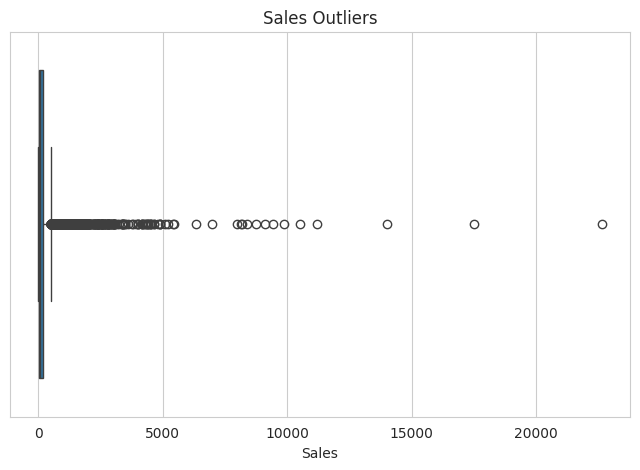

In [100]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Sales'])

plt.title('Sales Outliers')
plt.show()

### Insight
The Sales column contains several extreme values, indicating the presence of high-value transactions.

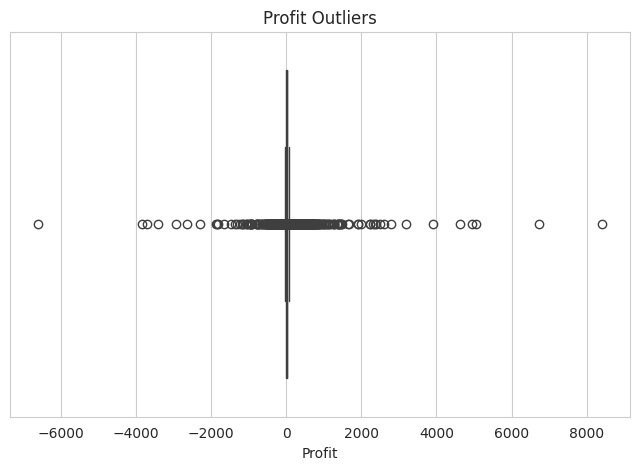

In [101]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Profit'])

plt.title('Profit Outliers')

plt.show()

### Insight
Profit includes both positive and negative outliers, suggesting that some transactions resulted in losses.

# 13) Correlation Analysis

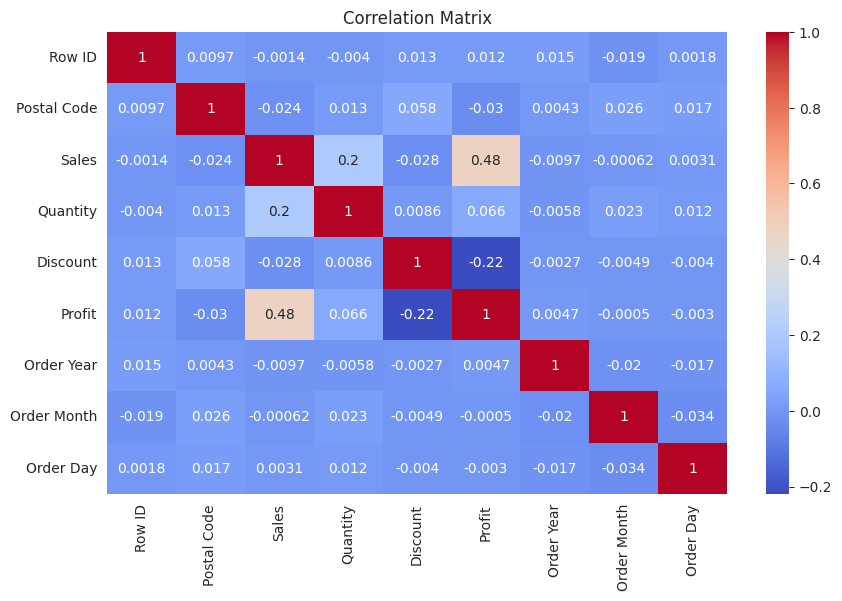

In [102]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

### Insight
Sales and Profit show a moderate positive relationship, while Discount appears to negatively affect Profit.

In [103]:
df.select_dtypes(include=np.number).corr()['Profit'].sort_values()

,Profit
Discount,-0.219487
Postal Code,-0.029961
Order Day,-0.002965
Order Month,-0.000502
Order Year,0.004670
Row ID,0.012497
Quantity,0.066253
Sales,0.479064
Profit,1.000000


### Insight
Discount has a negative correlation with Profit, suggesting that excessive discounts may reduce profitability.

# 14) Univariate Analysis

### Category Distribution

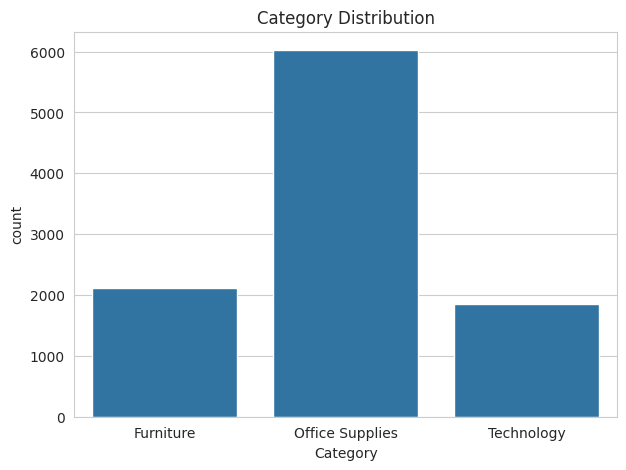

In [104]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x='Category')

plt.title('Category Distribution')

plt.show()

### Insight
Office Supplies appears to be the most frequent product category in the dataset.

### Category Sales

In [105]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

print(category_sales)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


### Insight
Technology generates the highest total sales among all product categories.

### Sales by Region

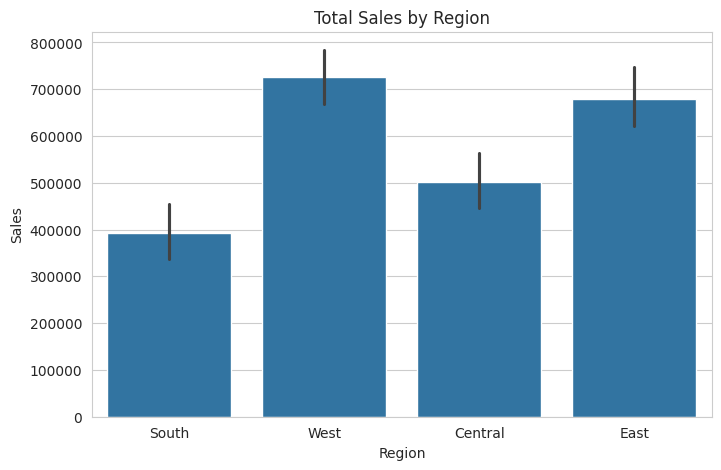

In [106]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Region',
    y='Sales',
    estimator=sum
)

plt.title('Total Sales by Region')

plt.show()

### Insight
The West region appears to generate the highest total sales compared to other regions.

# 15) Initial Business Questions


- Which category generates the highest sales?
- Which region is the most profitable?
- How do discounts affect profit?
- Which products perform poorly?
- Are there seasonal sales trends?

# 16)  Data Cleaning Summary



- Checked missing values
- Checked for duplicate rows
- Converted date columns
- Created new time-based features
- Detected outliers
- Prepared dataset for visualization and analysis

# 17) Dataset Final Shape

In [107]:
print("Final Dataset Shape:", df.shape)

Final Dataset Shape: (9994, 25)
